In [1]:
import sys
from pathlib import Path

project_root = Path("..")
sys.path.append(str(project_root))

In [2]:
import pandas as pd
from src.utils.constants import TEST_CSV

df = pd.read_csv(TEST_CSV)

In [3]:
display(df.head())
display(df.info())
display(df.describe())

,clip_name,clip_path,label,frame_count,duration_sec,fps,width,height,resolution
0,v_ApplyEyeMakeup_g01_c01,ApplyEyeMakeup\v_ApplyEyeMakeup_g01_c01.avi,ApplyEyeMakeup,164,6.56,25.0,320,240,320x240
1,v_ApplyEyeMakeup_g01_c02,ApplyEyeMakeup\v_ApplyEyeMakeup_g01_c02.avi,ApplyEyeMakeup,123,4.92,25.0,320,240,320x240
2,v_ApplyEyeMakeup_g01_c03,ApplyEyeMakeup\v_ApplyEyeMakeup_g01_c03.avi,ApplyEyeMakeup,259,10.36,25.0,320,240,320x240
3,v_ApplyEyeMakeup_g01_c04,ApplyEyeMakeup\v_ApplyEyeMakeup_g01_c04.avi,ApplyEyeMakeup,235,9.40,25.0,320,240,320x240
4,v_ApplyEyeMakeup_g01_c05,ApplyEyeMakeup\v_ApplyEyeMakeup_g01_c05.avi,ApplyEyeMakeup,296,11.84,25.0,320,240,320x240


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3783 entries, 0 to 3782
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   clip_name     3783 non-null   object 
 1   clip_path     3783 non-null   object 
 2   label         3783 non-null   object 
 3   frame_count   3783 non-null   int64  
 4   duration_sec  3783 non-null   float64
 5   fps           3783 non-null   float64
 6   width         3783 non-null   int64  
 7   height        3783 non-null   int64  
 8   resolution    3783 non-null   object 
dtypes: float64(2), int64(3), object(4)
memory usage: 266.1+ KB


None

,frame_count,duration_sec,fps,width,height
count,3783.000000,3783.000000,3783.000000,3783.000000,3783.000000
mean,184.345493,7.125823,25.931357,320.084589,239.985197
std,100.249556,3.849162,1.939558,2.600336,0.455059
min,30.000000,1.200000,25.000000,320.000000,226.000000
25%,111.000000,4.360000,25.000000,320.000000,240.000000
50%,161.000000,6.240000,25.000000,320.000000,240.000000
75%,240.500000,9.400000,25.000000,320.000000,240.000000
max,900.000000,33.760000,29.970030,400.000000,240.000000


In [11]:
total_frames = df["frame_count"].sum()
total_duration_hours = df["duration_sec"].sum() / 3600

print(f"Total videos: {len(df)}")
print(f"Total frames to process: {total_frames}")
print(f"Total duration (hours): {total_duration_hours:.2f}")
print(df["resolution"].value_counts())

Total videos: 3783
Total frames to process: 697379
Total duration (hours): 7.49
resolution
320x240    3779
400x226       4
Name: count, dtype: int64


In [5]:
df["label"].value_counts()

label
HorseRiding          49
BoxingPunchingBag    49
TennisSwing          49
PlayingDhol          49
CricketShot          49
                     ..
PlayingViolin        28
Rafting              28
Skijet               28
PlayingPiano         28
TaiChi               28
Name: count, Length: 101, dtype: int64

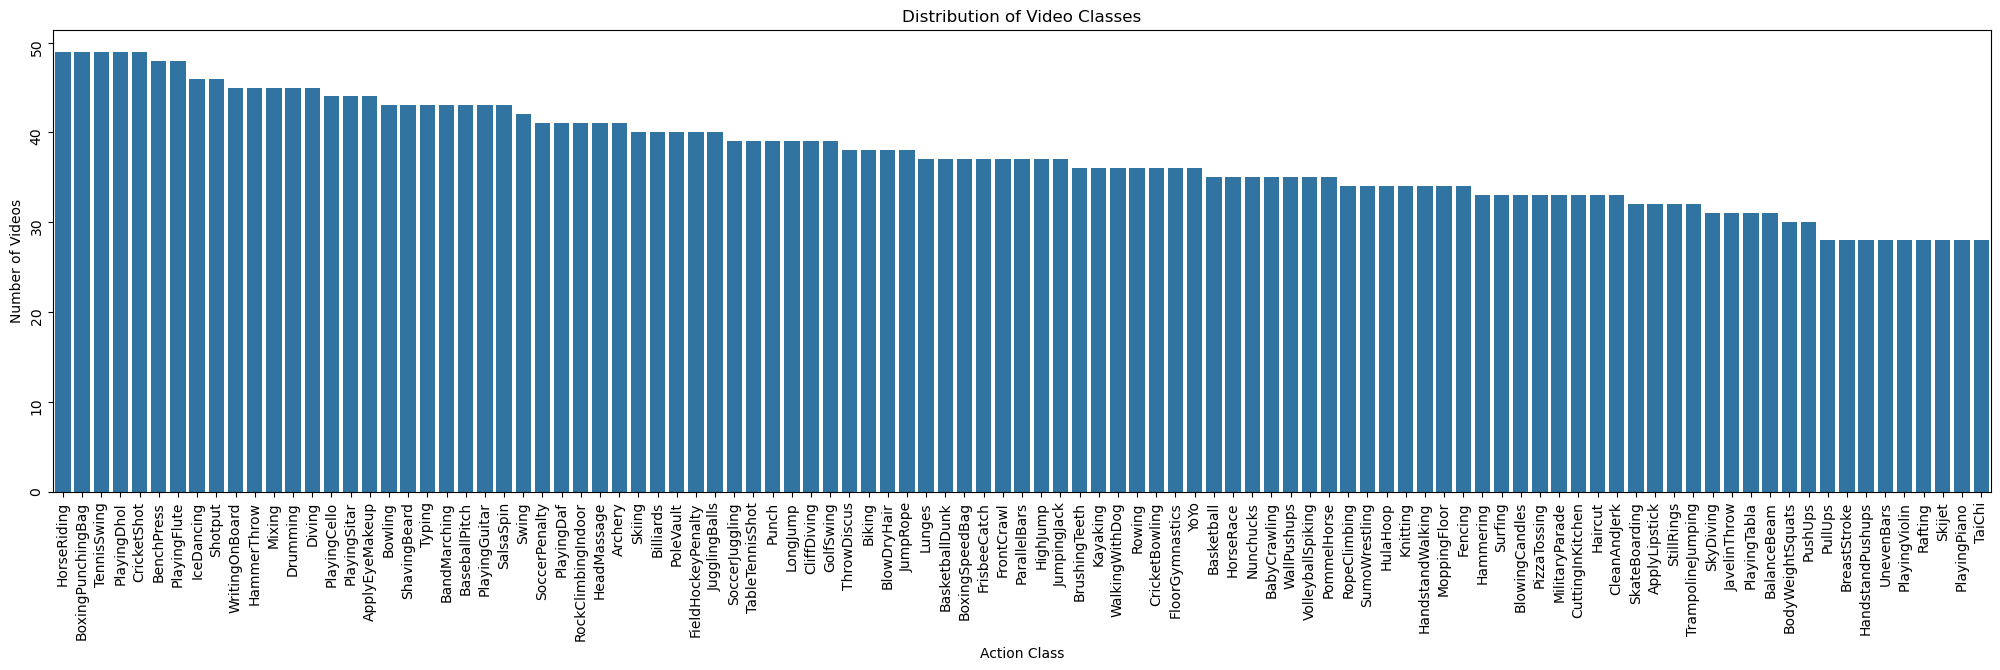

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(25, 6))
sns.countplot(
    x="label", data=df, order=df["label"].value_counts().index, ax=ax
)

ax.set_title("Distribution of Video Classes")
ax.set_xlabel("Action Class")
ax.set_ylabel("Number of Videos")
ax.tick_params(rotation=90)


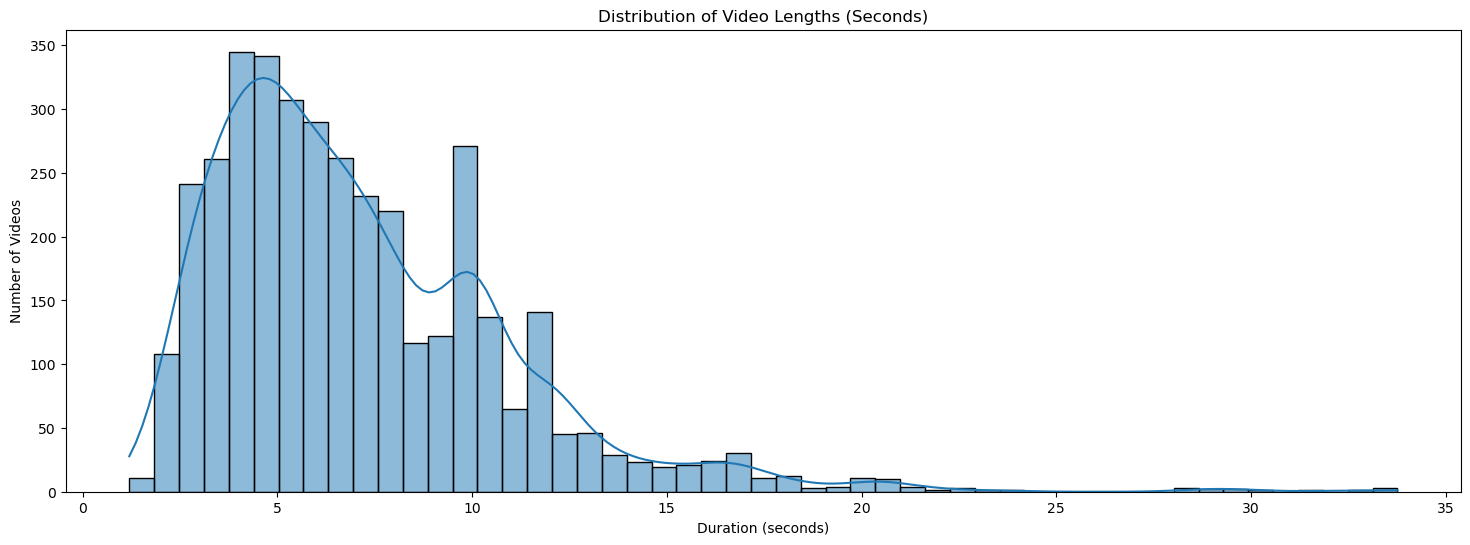

In [32]:
fig, axes = plt.subplots(figsize=(18, 6))
# histogram of video lengths
sns.histplot(df["duration_sec"], kde=True, ax=axes)
axes.set_title("Distribution of Video Lengths (Seconds)")
axes.set_xlabel("Duration (seconds)")
axes.set_ylabel("Number of Videos")

plt.show()